<a href="https://colab.research.google.com/github/mv24aat/Predictive-Qty-Recommendation-System-FYP/blob/main/Copy_of_FYP_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PREDICTIVE QUANTITY RECOMMENDATION SYSTEM for Warfarin Dosage



Importing necessary libraries and dataset



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/merged_patients.xls')

print(f'Shape: {df.shape}')
df.head()

Shape: (50000, 29)


,Patient_ID,Age,Sex,Weight_kg,Height_cm,Ethnicity,Hypertension,Diabetes,Chronic_Kidney_Disease,Heart_Failure,...,Diet_VitK_Intake,Final_Stable_Dose_mg,INR_Stabilization_Days,Adverse_Event,TTR_pct,CYP2C9_pcyp3,VKORC1_AA,On_Amiodarone,Alcohol_Score,VitK_Score
0,P000001,64,F,88,194,Caucasian,0,0,0,0,...,Low,2.4,5,NaN,66.8,1,0,0,2,0
1,P000002,50,M,101,175,Other,1,0,0,0,...,Low,3.8,8,NaN,72.4,0,0,0,2,0
2,P000003,66,F,85,162,Asian,0,0,0,0,...,Medium,3.1,7,NaN,58.0,0,0,0,3,1
3,P000004,58,M,83,178,African American,1,0,0,0,...,Low,5.4,6,NaN,77.9,0,0,0,1,0
4,P000005,61,F,75,194,Caucasian,1,0,0,1,...,High,6.6,7,NaN,70.6,0,0,0,1,2


Preprocessing and EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Patient_ID              50000 non-null  object 
 1   Age                     50000 non-null  int64  
 2   Sex                     50000 non-null  object 
 3   Weight_kg               50000 non-null  int64  
 4   Height_cm               50000 non-null  int64  
 5   Ethnicity               50000 non-null  object 
 6   Hypertension            50000 non-null  int64  
 7   Diabetes                50000 non-null  int64  
 8   Chronic_Kidney_Disease  50000 non-null  int64  
 9   Heart_Failure           50000 non-null  int64  
 10  Amiodarone              50000 non-null  int64  
 11  Antibiotics             50000 non-null  int64  
 12  Aspirin                 50000 non-null  int64  
 13  Statins                 50000 non-null  int64  
 14  CYP2C9                  50000 non-null

In [ ]:
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

print('Numeric columns:', num_cols)
print('\nCategorical columns:', cat_cols)

Numeric columns: ['Age', 'Weight_kg', 'Height_cm', 'Hypertension', 'Diabetes', 'Chronic_Kidney_Disease', 'Heart_Failure', 'Amiodarone', 'Antibiotics', 'Aspirin', 'Statins', 'Final_Stable_Dose_mg', 'INR_Stabilization_Days', 'TTR_pct', 'CYP2C9_pcyp3', 'VKORC1_AA', 'On_Amiodarone', 'Alcohol_Score', 'VitK_Score']

Categorical columns: ['Patient_ID', 'Sex', 'Ethnicity', 'CYP2C9', 'VKORC1', 'CYP4F2', 'Alcohol_Intake', 'Smoking_Status', 'Diet_VitK_Intake', 'Adverse_Event']


In [ ]:
df = df.drop(columns=['On_Amiodarone'])  # identical to Amiodarone


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Patient_ID              50000 non-null  object 
 1   Age                     50000 non-null  int64  
 2   Sex                     50000 non-null  object 
 3   Weight_kg               50000 non-null  int64  
 4   Height_cm               50000 non-null  int64  
 5   Ethnicity               50000 non-null  object 
 6   Hypertension            50000 non-null  int64  
 7   Diabetes                50000 non-null  int64  
 8   Chronic_Kidney_Disease  50000 non-null  int64  
 9   Heart_Failure           50000 non-null  int64  
 10  Amiodarone              50000 non-null  int64  
 11  Antibiotics             50000 non-null  int64  
 12  Aspirin                 50000 non-null  int64  
 13  Statins                 50000 non-null  int64  
 14  CYP2C9                  50000 non-null

In [ ]:
current_num_cols = [col for col in num_cols if col in df.columns]
df[current_num_cols].describe().round(2)

,Age,Weight_kg,Height_cm,Hypertension,Diabetes,Chronic_Kidney_Disease,Heart_Failure,Amiodarone,Antibiotics,Aspirin,Statins,Final_Stable_Dose_mg,INR_Stabilization_Days,TTR_pct,CYP2C9_pcyp3,VKORC1_AA,Alcohol_Score,VitK_Score
count,50000.00,50000.00,50000.00,50000.00,50000.0,50000.0,50000.0,50000.0,50000.0,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,67.43,74.61,169.53,0.40,0.2,0.2,0.2,0.1,0.1,0.30,0.30,3.29,7.72,70.27,0.26,0.14,0.96,0.80
std,9.88,14.67,9.76,0.49,0.4,0.4,0.4,0.3,0.3,0.46,0.46,1.62,2.80,10.56,0.44,0.35,0.93,0.75
min,40.00,45.00,150.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,1.00,0.00,30.00,0.00,0.00,0.00,0.00
25%,61.00,64.00,163.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,2.00,6.00,63.10,0.00,0.00,0.00,0.00
50%,67.00,74.00,169.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,3.00,8.00,70.40,0.00,0.00,1.00,1.00
75%,74.00,85.00,176.00,1.00,0.0,0.0,0.0,0.0,0.0,1.00,1.00,4.40,9.00,77.50,1.00,0.00,2.00,1.00
max,90.00,120.00,200.00,1.00,1.0,1.0,1.0,1.0,1.0,1.00,1.00,10.10,21.00,95.00,1.00,1.00,3.00,2.00


In [ ]:
for col in ['Sex', 'Ethnicity', 'CYP2C9', 'VKORC1', 'CYP4F2',
            'Alcohol_Intake', 'Smoking_Status', 'Diet_VitK_Intake',
            'Adverse_Event']:
    print(f'\n--- {col} ---')
    print(df[col].value_counts(dropna=False))



--- Sex ---
Sex
M    27418
F    22582
Name: count, dtype: int64

--- Ethnicity ---
Ethnicity
Caucasian           22582
Asian               10025
African American     7467
Hispanic             7456
Other                2470
Name: count, dtype: int64

--- CYP2C9 ---
CYP2C9
*1/*1    25673
*1/*2     9025
*1/*3     8740
*2/*3     2942
*2/*2     2397
*3/*3     1223
Name: count, dtype: int64

--- VKORC1 ---
VKORC1
G/G    24499
A/G    18319
A/A     7182
Name: count, dtype: int64

--- CYP4F2 ---
CYP4F2
C/C    29929
C/T    15038
T/T     5033
Name: count, dtype: int64

--- Alcohol_Intake ---
Alcohol_Intake
NaN         19925
Light       14831
Moderate    12632
Heavy        2612
Name: count, dtype: int64

--- Smoking_Status ---
Smoking_Status
Non-smoker       30108
Former Smoker    12482
Smoker            7410
Name: count, dtype: int64

--- Diet_VitK_Intake ---
Diet_VitK_Intake
Medium    20065
Low       19972
High       9963
Name: count, dtype: int64

--- Adverse_Event ---
Adverse_Event
NaN       

In [ ]:
Duplicate = df.duplicated().sum
print(Duplicate)

<bound method Series.sum of 0        False
1        False
2        False
3        False
4        False
         ...  
49995    False
49996    False
49997    False
49998    False
49999    False
Length: 50000, dtype: bool>


                Missing count  Missing %
Alcohol_Intake          19925       39.8
Adverse_Event           41736       83.5


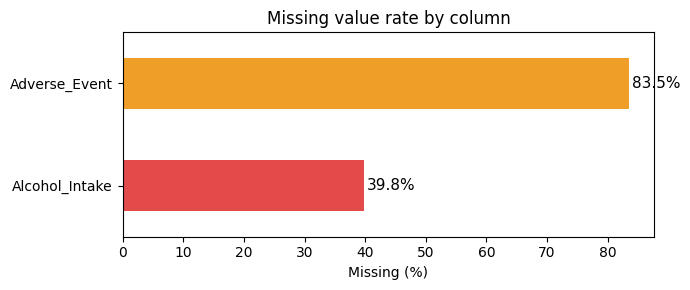

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing count'] > 0]
print(missing_df)

# Plot
fig, ax = plt.subplots(figsize=(7, 3))
missing_df['Missing %'].plot(kind='barh', ax=ax, color=['#E24B4A', '#EF9F27'])
ax.set_xlabel('Missing (%)')
ax.set_title('Missing value rate by column')
for i, v in enumerate(missing_df['Missing %']):
    ax.text(v + 0.5, i, f'{v}%', va='center', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
df['Adverse_Event_bin'] = df['Adverse_Event'].notna().astype(int)
print('Adverse events (recoded):')
print(df['Adverse_Event_bin'].value_counts())

Adverse events (recoded):
Adverse_Event_bin
0    41736
1     8264
Name: count, dtype: int64


In [ ]:
df['Adverse_Event'] = df['Adverse_Event'].fillna('No Event')
df['Alcohol_Intake'] = df['Alcohol_Intake'].fillna('Non-drinker')

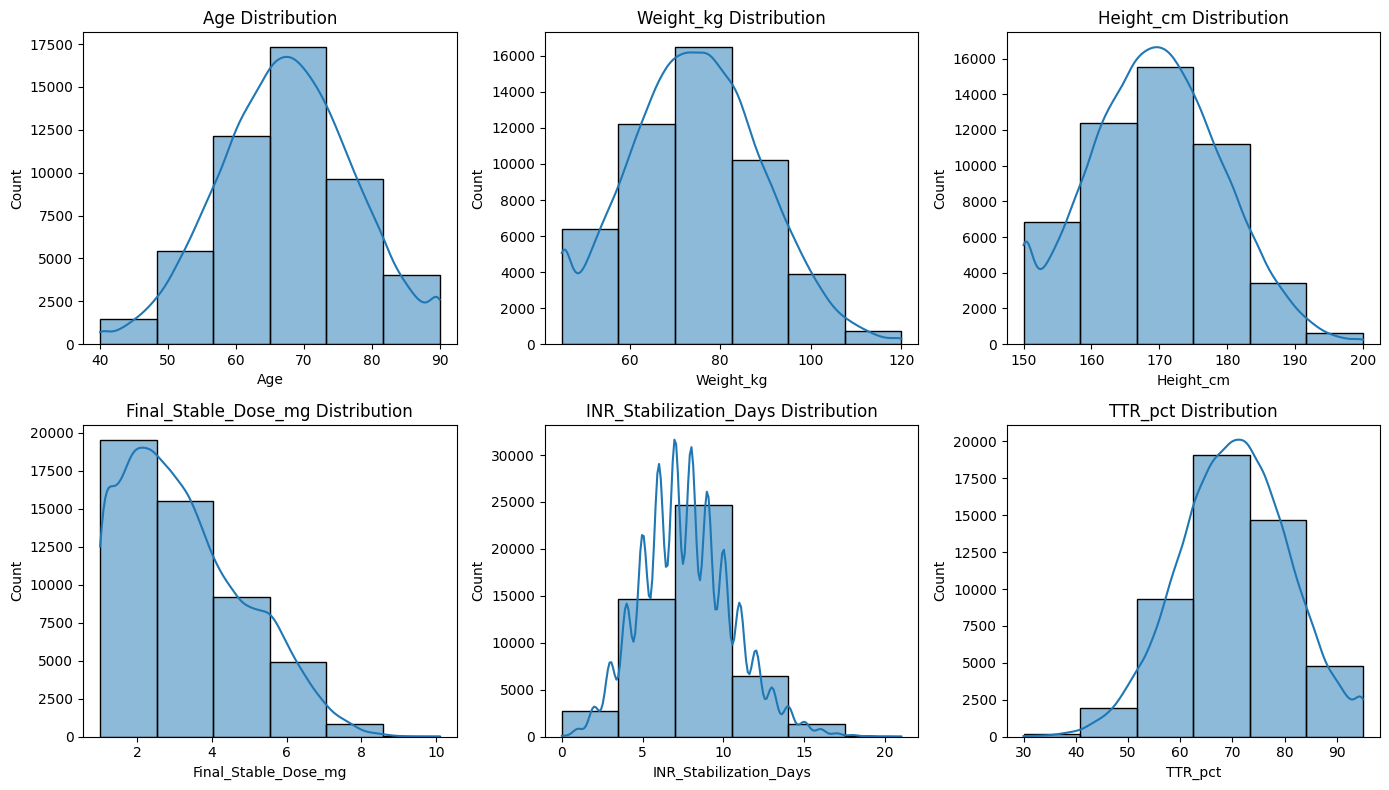

In [ ]:
bins = 6

fig, ax = plt.subplots(2, 3, figsize=(14, 8))

sns.histplot(df['Age'], bins=bins, kde=True, ax=ax[0, 0])
ax[0, 0].set_title('Age Distribution')

sns.histplot(df['Weight_kg'], bins=bins, kde=True, ax=ax[0, 1])
ax[0, 1].set_title('Weight_kg Distribution')

sns.histplot(df['Height_cm'], bins=bins, kde=True, ax=ax[0, 2])
ax[0, 2].set_title('Height_cm Distribution')

sns.histplot(df['Final_Stable_Dose_mg'], bins=bins, kde=True, ax=ax[1, 0])
ax[1, 0].set_title('Final_Stable_Dose_mg Distribution')

sns.histplot(df['INR_Stabilization_Days'], bins=bins, kde=True, ax=ax[1, 1])
ax[1, 1].set_title('INR_Stabilization_Days Distribution')

sns.histplot(df['TTR_pct'], bins=bins, kde=True, ax=ax[1, 2])
ax[1, 2].set_title('TTR_pct Distribution')

plt.tight_layout()
plt.show()

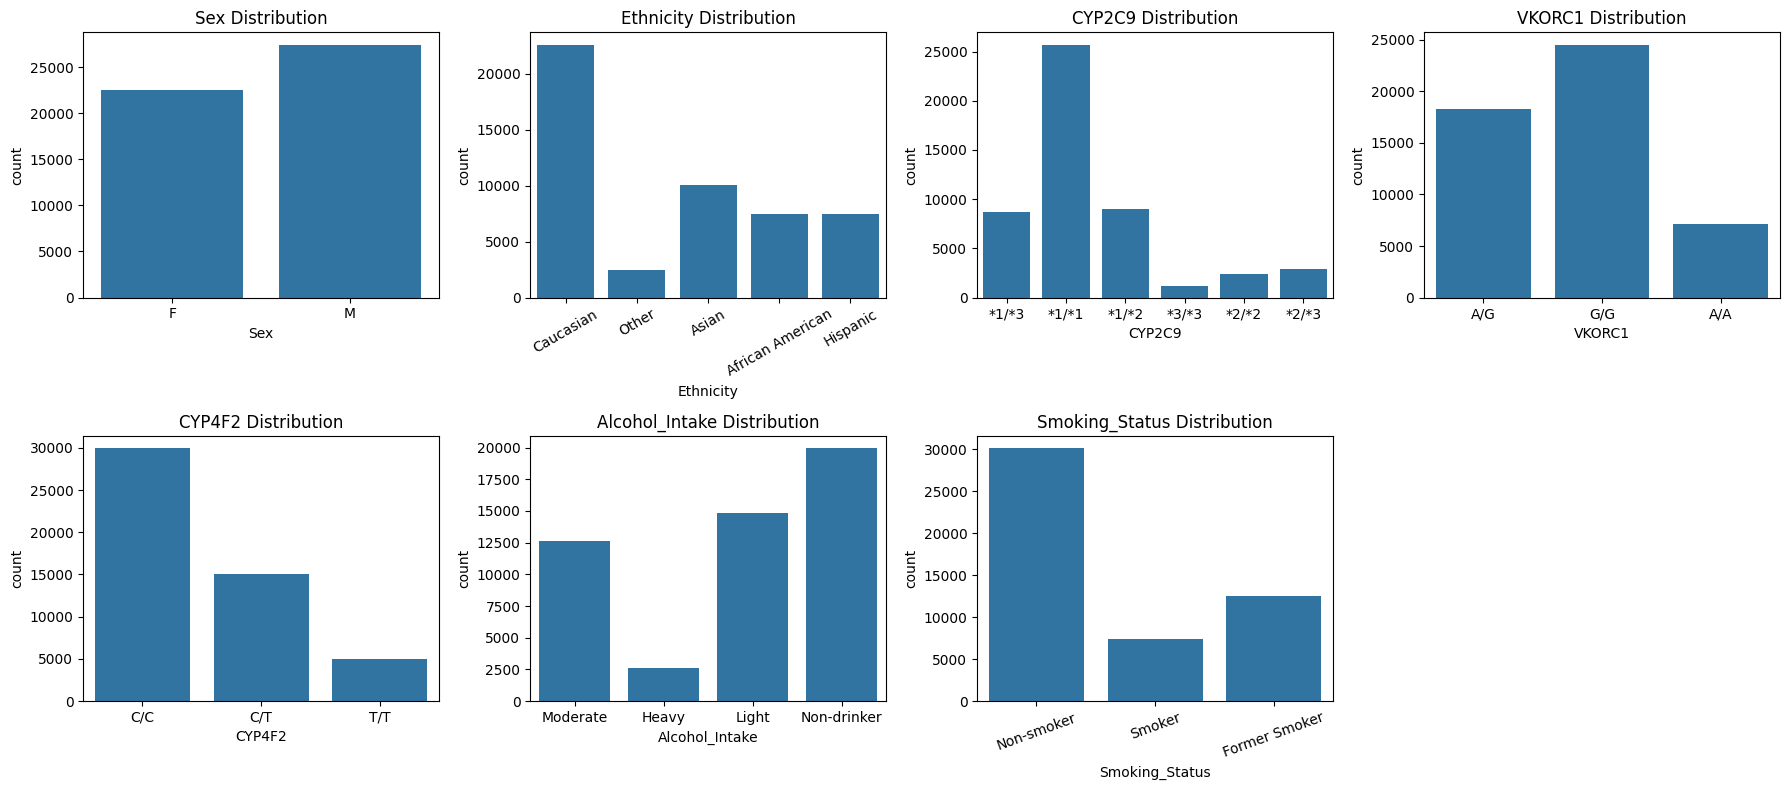

In [ ]:
# Create a 2x4 grid of subplots to fit 7 categorical columns
fig, ax = plt.subplots(2, 4, figsize=(18, 8))

# Plot the count distribution of 'Sex'
sns.countplot(data=df, x='Sex', ax=ax[0, 0])
ax[0, 0].set_title('Sex Distribution')

# Plot the count distribution of 'Ethnicity'
sns.countplot(data=df, x='Ethnicity', ax=ax[0, 1])
ax[0, 1].set_title('Ethnicity Distribution')
ax[0, 1].tick_params(axis='x', rotation=30)

# Plot the count distribution of 'CYP2C9'
sns.countplot(data=df, x='CYP2C9', ax=ax[0, 2])
ax[0, 2].set_title('CYP2C9 Distribution')

# Plot the count distribution of 'VKORC1'
sns.countplot(data=df, x='VKORC1', ax=ax[0, 3])
ax[0, 3].set_title('VKORC1 Distribution')

# Plot the count distribution of 'CYP4F2'
sns.countplot(data=df, x='CYP4F2', ax=ax[1, 0])
ax[1, 0].set_title('CYP4F2 Distribution')

# Plot the count distribution of 'Alcohol_Intake'
sns.countplot(data=df, x='Alcohol_Intake', ax=ax[1, 1])
ax[1, 1].set_title('Alcohol_Intake Distribution')

# Plot the count distribution of 'Smoking_Status'
sns.countplot(data=df, x='Smoking_Status', ax=ax[1, 2])
ax[1, 2].set_title('Smoking_Status Distribution')
ax[1, 2].tick_params(axis='x', rotation=20)

# Hide the unused last subplot
ax[1, 3].set_visible(False)

# Adjust the layout to avoid overlap of plot elements
plt.tight_layout()

# Display the plot
plt.show()


In [ ]:
# Loop through the list of genes and print the normalized value counts for each
for gene in ['CYP2C9', 'VKORC1', 'CYP4F2']:
    print(f'\n{gene} Distribution:\n', df[gene].value_counts(normalize=True))


CYP2C9 Distribution:
 CYP2C9
*1/*1    0.51346
*1/*2    0.18050
*1/*3    0.17480
*2/*3    0.05884
*2/*2    0.04794
*3/*3    0.02446
Name: proportion, dtype: float64

VKORC1 Distribution:
 VKORC1
G/G    0.48998
A/G    0.36638
A/A    0.14364
Name: proportion, dtype: float64

CYP4F2 Distribution:
 CYP4F2
C/C    0.59858
C/T    0.30076
T/T    0.10066
Name: proportion, dtype: float64


In [ ]:
display('Alcohol Intake:', df['Alcohol_Intake'].value_counts(normalize=True))

'Alcohol Intake:'

,proportion
Alcohol_Intake,
Non-drinker,0.39850
Light,0.29662
Moderate,0.25264
Heavy,0.05224


In [ ]:
display('Adverse Events (Percentage):', df['Adverse_Event'].value_counts(normalize=True))
display('Adverse Events (Count):', df['Adverse_Event'].value_counts())

'Adverse Events (Percentage):'

,proportion
Adverse_Event,
No Event,0.83472
Bleeding,0.09568
Clotting,0.06960


'Adverse Events (Count):'

,count
Adverse_Event,
No Event,41736
Bleeding,4784
Clotting,3480


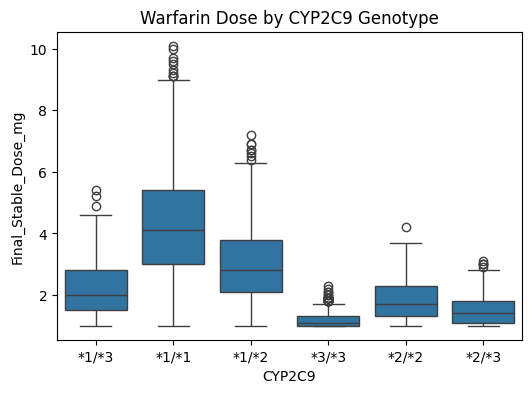

In [ ]:
plt.figure(figsize=(6, 4))

# Plot the boxplot using Seaborn
sns.boxplot(data=df, x='CYP2C9', y='Final_Stable_Dose_mg')
plt.title('Warfarin Dose by CYP2C9 Genotype')
plt.show()

In [ ]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import mlflow
import sklearn
import mlflow.sklearn

In [ ]:
pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.4/87.4 kB 4.0 MB/s eta 0:00:00


In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from category_encoders import OneHotEncoder

In [ ]:
df.columns

Index(['Patient_ID', 'Age', 'Sex', 'Weight_kg', 'Height_cm', 'Ethnicity',
       'Hypertension', 'Diabetes', 'Chronic_Kidney_Disease', 'Heart_Failure',
       'Amiodarone', 'Antibiotics', 'Aspirin', 'Statins', 'CYP2C9', 'VKORC1',
       'CYP4F2', 'Alcohol_Intake', 'Smoking_Status', 'Diet_VitK_Intake',
       'Final_Stable_Dose_mg', 'INR_Stabilization_Days', 'Adverse_Event',
       'TTR_pct', 'CYP2C9_pcyp3', 'VKORC1_AA', 'Alcohol_Score', 'VitK_Score',
       'Adverse_Event_bin'],
      dtype='object')

In [ ]:
features = [
    'Age', 'Sex', 'Weight_kg', 'Height_cm', 'Ethnicity',
    'Amiodarone', 'Alcohol_Score', 'VitK_Score'
]

X = df[features]
y = df['Final_Stable_Dose_mg']

In [ ]:
X.head()

,Age,Sex,Weight_kg,Height_cm,Ethnicity,Amiodarone,Alcohol_Score,VitK_Score
0,64,F,88,194,Caucasian,0,2,0
1,50,M,101,175,Other,0,2,0
2,66,F,85,162,Asian,0,3,1
3,58,M,83,178,African American,0,1,0
4,61,F,75,194,Caucasian,0,1,2


In [ ]:
from sklearn.pipeline import Pipeline

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = Pipeline([
            ('ohe', OneHotEncoder(use_cat_names=True)),
            ('dt', DecisionTreeRegressor(random_state=42))])
model.fit(X_train, y_train)

Pipeline(steps=[('ohe',
                 OneHotEncoder(cols=['Sex', 'Ethnicity'], use_cat_names=True)),
                ('dt', DecisionTreeRegressor(random_state=42))])

In [ ]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [ ]:
mlflow.log_params(model.named_steps['dt'].get_params())
mlflow.log_metrics({"mae": mae, "rmse": rmse, "r2": r2})


2026/08/04 21:16:29 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/04 21:16:29 INFO mlflow.store.db.utils: Updating database tables


In [ ]:
mlflow.sklearn.log_model(model, 'model', serialization_format='cloudpickle')

2026/08/04 21:16:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/04 21:16:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [ ]:
engineered_df = df.copy()

engineered_df["BMI"] = engineered_df["Weight_kg"] / ((engineered_df["Height_cm"] / 100) ** 2)

comorbs = ["Hypertension", "Diabetes", "Chronic_Kidney_Disease", "Heart_Failure"]
engineered_df["Comorbidity_Burden"] = engineered_df[comorbs].sum(axis=1)

meds = ["Amiodarone", "Antibiotics", "Aspirin", "Statins"]
engineered_df["Polypharmacy_Index"] = engineered_df[meds].sum(axis=1)

In [ ]:
engineered_df.columns
test_check = engineered_df[['Weight_kg', 'Height_cm', 'BMI']]
test_check.corr()

,Weight_kg,Height_cm,BMI
Weight_kg,1.000000,0.003907,0.857206
Height_cm,0.003907,1.000000,-0.499117
BMI,0.857206,-0.499117,1.000000


In [ ]:
engineered_features = ['Age', 'Sex', 'BMI', 'Weight_kg', 'Height_cm', 'Ethnicity',
                       'Alcohol_Intake', 'Smoking_Status', 'Diet_VitK_Intake',
                       'CYP2C9', 'VKORC1', 'CYP4F2',
                       'Amiodarone', 'Comorbidity_Burden', 'Polypharmacy_Index']

In [ ]:
print(engineered_features)

['Age', 'Sex', 'BMI', 'Weight_kg', 'Height_cm', 'Ethnicity', 'Alcohol_Intake', 'Smoking_Status', 'Diet_VitK_Intake', 'CYP2C9', 'VKORC1', 'CYP4F2', 'Amiodarone', 'Comorbidity_Burden', 'Polypharmacy_Index']


In [ ]:
# Feature engineering
df['CYP2C9_variant_count'] = df['CYP2C9'].apply(
    lambda g: sum(1 for a in g.replace('*', '').split('/') if a != '1')
)
df['VKORC1_A_count'] = df['VKORC1'].apply(lambda g: g.count('A'))
df['CYP4F2_T_count'] = df['CYP4F2'].apply(lambda g: g.count('T'))
df['BMI'] = df['Weight_kg'] / (df['Height_cm'] / 100) ** 2

cols = ['Age', 'BMI', 'CYP2C9_variant_count', 'VKORC1_A_count', 'CYP4F2_T_count',
        'Alcohol_Score', 'VitK_Score', 'Amiodarone', 'Final_Stable_Dose_mg',
        'INR_Stabilization_Days', 'TTR_pct']

corr = df[cols].corr(method='pearson').round(2)
print(corr.to_string())

                         Age   BMI  CYP2C9_variant_count  VKORC1_A_count  CYP4F2_T_count  Alcohol_Score  VitK_Score  Amiodarone  Final_Stable_Dose_mg  INR_Stabilization_Days  TTR_pct
Age                     1.00  0.00                 -0.00           -0.00             0.0          -0.00        0.01       -0.00                 -0.07                    0.01    -0.01
BMI                     0.00  1.00                 -0.01            0.00            -0.0           0.00        0.00       -0.00                  0.07                    0.00     0.00
CYP2C9_variant_count   -0.00 -0.01                  1.00            0.05            -0.0          -0.01        0.00        0.00                 -0.62                   -0.01     0.02
VKORC1_A_count         -0.00  0.00                  0.05            1.00            -0.0          -0.00        0.01        0.01                 -0.60                   -0.00     0.01
CYP4F2_T_count          0.00 -0.00                 -0.00           -0.00             

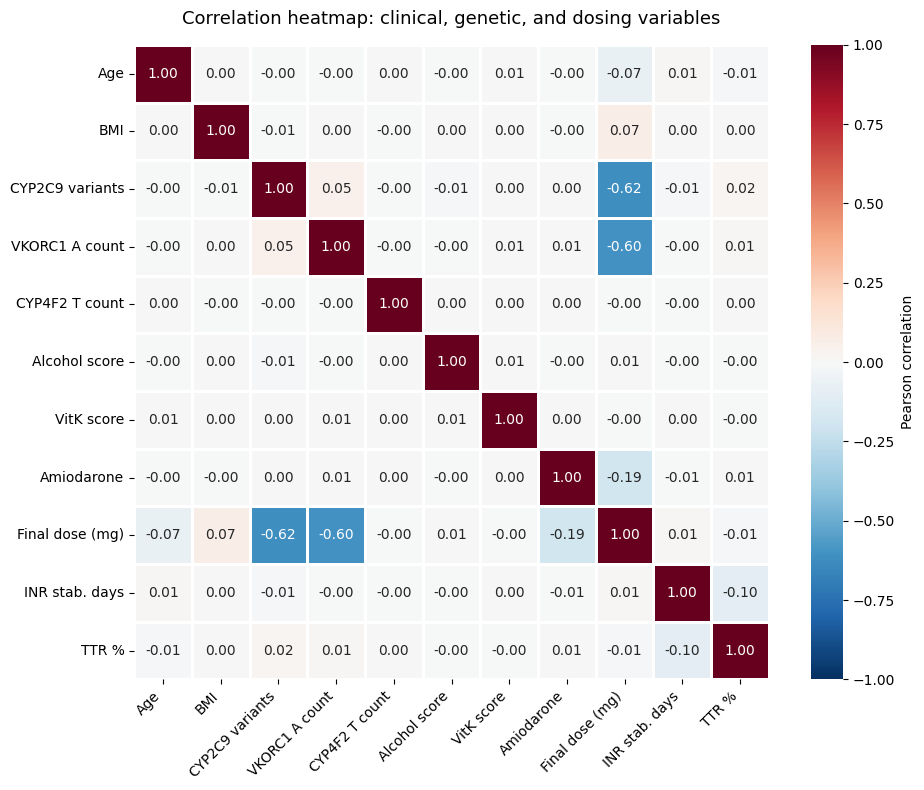

In [ ]:
# 2. Feature engineering
df['CYP2C9_variant_count'] = df['CYP2C9'].apply(
    lambda g: sum(1 for a in g.replace('*', '').split('/') if a != '1')
)
df['VKORC1_A_count'] = df['VKORC1'].apply(lambda g: g.count('A'))
df['CYP4F2_T_count'] = df['CYP4F2'].apply(lambda g: g.count('T'))
df['BMI'] = df['Weight_kg'] / (df['Height_cm'] / 100) ** 2

# 3. Select variables and compute correlation matrix
cols = ['Age', 'BMI', 'CYP2C9_variant_count', 'VKORC1_A_count', 'CYP4F2_T_count',
        'Alcohol_Score', 'VitK_Score', 'Amiodarone', 'Final_Stable_Dose_mg',
        'INR_Stabilization_Days', 'TTR_pct']

corr = df[cols].corr(method='pearson')

# 4. Nicer labels for display
display_labels = ['Age', 'BMI', 'CYP2C9 variants', 'VKORC1 A count', 'CYP4F2 T count',
                   'Alcohol score', 'VitK score', 'Amiodarone', 'Final dose (mg)',
                   'INR stab. days', 'TTR %']
corr.index = display_labels
corr.columns = display_labels

# 5. Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',       # diverging: blue = negative, red = positive
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=1,
    linecolor='white',
    cbar_kws={'label': 'Pearson correlation'}
)
plt.title('Correlation heatmap: clinical, genetic, and dosing variables', fontsize=13, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('warfarin_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
X_eng = engineered_df[engineered_features].copy()
y_eng = engineered_df['Final_Stable_Dose_mg']

# Impute missing numerical values before splitting
# These columns were identified as having 1 NaN each in the original df and carried over
for col in ['On_Amiodarone', 'Alcohol_Score', 'VitK_Score']:
    if col in X_eng.columns:
        X_eng[col] = X_eng[col].fillna(X_eng[col].median())

X_train, X_test, y_train, y_test = train_test_split(X_eng, y_eng, test_size=0.2, random_state=42)
ohe = OneHotEncoder(use_cat_names=True)
X_train_encoded = ohe.fit_transform(X_train)
X_test_encoded = ohe.transform(X_test)

In [ ]:
X_train_encoded.columns

Index(['Age', 'Sex_M', 'Sex_F', 'BMI', 'Weight_kg', 'Height_cm',
       'Ethnicity_Caucasian', 'Ethnicity_African American', 'Ethnicity_Asian',
       'Ethnicity_Hispanic', 'Ethnicity_Other', 'Alcohol_Intake_Light',
       'Alcohol_Intake_Non-drinker', 'Alcohol_Intake_Heavy',
       'Alcohol_Intake_Moderate', 'Smoking_Status_Former Smoker',
       'Smoking_Status_Non-smoker', 'Smoking_Status_Smoker',
       'Diet_VitK_Intake_Low', 'Diet_VitK_Intake_High',
       'Diet_VitK_Intake_Medium', 'CYP2C9_*1/*1', 'CYP2C9_*1/*3',
       'CYP2C9_*2/*2', 'CYP2C9_*3/*3', 'CYP2C9_*1/*2', 'CYP2C9_*2/*3',
       'VKORC1_G/G', 'VKORC1_A/G', 'VKORC1_A/A', 'CYP4F2_C/C', 'CYP4F2_C/T',
       'CYP4F2_T/T', 'Amiodarone', 'Comorbidity_Burden', 'Polypharmacy_Index'],
      dtype='object')

In [ ]:
mlflow.end_run()

In [ ]:
with mlflow.start_run(run_name='DecisionTree_Engineered'):
    model = DecisionTreeRegressor(random_state=42)
    model.fit(X_train_encoded, y_train)
    y_pred = model.predict(X_test_encoded)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    mlflow.log_params(model.get_params())
    mlflow.log_metrics({"mae": mae, "rmse": rmse, "r2": r2})
    mlflow. sklearn.log_model(model, 'model')

2026/08/04 21:16:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [ ]:
with mlflow.start_run(run_name='ExtraTree_Engineered'):


    model = ExtraTreesRegressor(random_state=42, n_estimators=300, max_depth=None)
    model.fit(X_train_encoded, y_train)


    y_pred = model.predict(X_test_encoded)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    mlflow.log_params(model.get_params())


    mlflow.log_metrics({"mae": mae, "rmse": rmse, "r2": r2})

    mlflow.sklearn.log_model(model, 'model')

2026/08/04 21:18:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [ ]:
run_name = 'ExtraTree_Engineered'
run = mlflow.search_runs(filter_string=f"tags.mlflow.runName = '{run_name}'")
model_uri = f"runs:/{run.run_id[0]}/model"
model_name = 'Genexa_Warfarin_Dosing'
mlflow.register_model(model_uri=model_uri, name=model_name)
genexa_model = mlflow.sklearn.load_model("models:/Genexa_Warfarin_Dosing/1")


Successfully registered model 'Genexa_Warfarin_Dosing'.
2026/08/04 21:20:57 WARNING mlflow.tracking._model_registry.fluent: Run with id 3fad474fceff4529a867f24ef58cd0ed has no artifacts at artifact path 'model', registering model based on models:/m-9595f98268e54c64a881930bf4c04a28 instead
Created version '1' of model 'Genexa_Warfarin_Dosing'.


<Axes: ylabel='Model'>

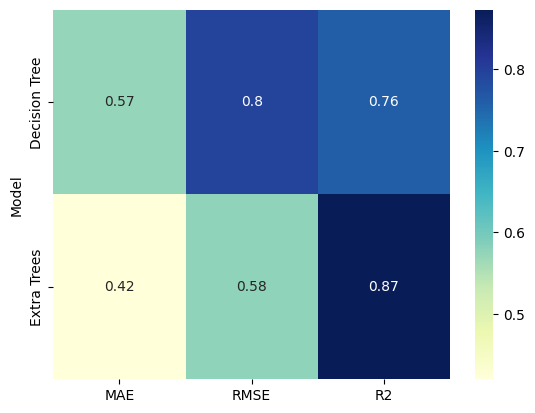

In [ ]:
dt_run = mlflow.search_runs(filter_string="tags.mlflow.runName = 'DecisionTree_Engineered'").iloc[0]
mae_dt = dt_run['metrics.mae']
rmse_dt = dt_run['metrics.rmse']
r2_dt = dt_run['metrics.r2']

et_run = mlflow.search_runs(filter_string="tags.mlflow.runName = 'ExtraTree_Engineered'").iloc[0]
mae_et = et_run['metrics.mae']
rmse_et = et_run['metrics.rmse']
r2_et = et_run['metrics.r2']

results = pd.DataFrame({
    "Model":["Decision Tree","Extra Trees"],
    "MAE":[mae_dt,mae_et],
    "RMSE":[rmse_dt,rmse_et],
    "R2":[r2_dt,r2_et]
})

sns.heatmap(
    results.set_index("Model"),
    annot=True,
    cmap="YlGnBu"
)

Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import RandomizedSearchCV


In [ ]:
dt_param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_leaf": [1, 2, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

dt_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=dt_param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)
dt_search.fit(X_train_encoded, y_train)

print("Best Decision Tree params:", dt_search.best_params_)
print("Best CV MAE:", -dt_search.best_score_)

Best Decision Tree params: {'max_depth': 10, 'min_samples_leaf': 20, 'min_samples_split': 2}
Best CV MAE: 0.4079720694745029


In [ ]:
# Refit best model, evaluate on the held-out test set
best_dt = dt_search.best_estimator_
y_pred_dt = best_dt.predict(X_test_encoded)
mae_dt_tuned = mean_absolute_error(y_test, y_pred_dt)
rmse_dt_tuned = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt_tuned = r2_score(y_test, y_pred_dt)

with mlflow.start_run(run_name="DecisionTree_Tuned"):
    mlflow.log_params(dt_search.best_params_)
    mlflow.log_metrics({
        "mae": mae_dt_tuned, "rmse": rmse_dt_tuned, "r2": r2_dt_tuned,
        "cv_mae": -dt_search.best_score_,
    })
    mlflow.sklearn.log_model(best_dt, "model")


2026/08/04 21:22:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [ ]:
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV
from scipy import sparse
from sklearn.impute import SimpleImputer


imputer = SimpleImputer(strategy='constant', fill_value=0)

# Temporarily store original X_train_encoded and X_test_encoded if they are sparse
original_X_train_encoded = X_train_encoded
original_X_test_encoded = X_test_encoded

# where X_train_encoded might already be a sparse matrix from a previous run
if sparse.issparse(original_X_train_encoded):
    # Assuming 'ohe' (OneHotEncoder) from QkRiaFrucaRF is in scope and its state is preserved
    feature_names = ohe.get_feature_names_out()
    X_train_encoded_for_imputation = pd.DataFrame(original_X_train_encoded.toarray(), columns=feature_names)
    X_test_encoded_for_imputation = pd.DataFrame(original_X_test_encoded.toarray(), columns=feature_names)
else:

    X_train_encoded_for_imputation = original_X_train_encoded
    X_test_encoded_for_imputation = original_X_test_encoded

# Perform imputation on the dense DataFrames
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train_encoded_for_imputation), columns=X_train_encoded_for_imputation.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test_encoded_for_imputation), columns=X_test_encoded_for_imputation.columns)

# Convert to sparse matrix using the imputed DataFrames
X_train_encoded = sparse.csr_matrix(X_train_imputed.values)
X_test_encoded = sparse.csr_matrix(X_test_imputed.values)

In [ ]:
#et_param_grid = {
   # "n_estimators": [50, 100, 200],
    #"max_depth": [None, 10, 20],
    #"min_samples_leaf": [1, 2, 5],
    #"max_features": ["sqrt", "log2"],
#}

# Ran all different comnination anf this was the best. time saving
et_param_grid = {
    "n_estimators": [200],
    "max_depth": [None],
    "min_samples_leaf": [2],
    "max_features": ["sqrt"],
}


In [ ]:
et_search = RandomizedSearchCV(
    estimator=ExtraTreesRegressor(random_state=42, n_jobs=1),
    param_distributions= et_param_grid,
    n_iter=10,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=2,
    pre_dispatch="2*n_jobs",
    verbose=2,
    random_state=42,
    return_train_score=True,
)


In [ ]:
et_search.fit(X_train_encoded, y_train)



/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=ExtraTreesRegressor(n_jobs=1, random_state=42),
                   n_jobs=2,
                   param_distributions={'max_depth': [None],
                                        'max_features': ['sqrt'],
                                        'min_samples_leaf': [2],
                                        'n_estimators': [200]},
                   random_state=42, return_train_score=True,
                   scoring='neg_mean_absolute_error', verbose=2)

In [ ]:
et_search.fit(X_train_encoded, y_train)
print("Best Extra Trees params (from search):", et_search.best_params_)
print("Best CV MAE:", -et_search.best_score_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best Extra Trees params (from search): {'n_estimators': 200, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Best CV MAE: 0.41655304420482003


In [ ]:
final_et_params = {**et_search.best_params_, "n_estimators": 300}
best_et = ExtraTreesRegressor(random_state=42, n_jobs=-1, **final_et_params)
best_et.fit(X_train_encoded, y_train)

y_pred_et = best_et.predict(X_test_encoded)
mae_et_tuned = mean_absolute_error(y_test, y_pred_et)
rmse_et_tuned = np.sqrt(mean_squared_error(y_test, y_pred_et))
r2_et_tuned = r2_score(y_test, y_pred_et)

with mlflow.start_run(run_name="ExtraTree_Tuned"):
    mlflow.log_params(final_et_params)
    mlflow.log_metrics({
        "mae": mae_et_tuned, "rmse": rmse_et_tuned, "r2": r2_et_tuned,
        "cv_mae_at_search_size": -et_search.best_score_,
    })
    mlflow.sklearn.log_model(best_et, "model")

2026/08/04 21:45:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [ ]:
# Comparison table: baseline vs tuned
comparison = pd.DataFrame({
    "Model": ["Decision Tree (default)", "Decision Tree (tuned)",
              "Extra Trees (default, n=300)", "Extra Trees (tuned)"],
    "MAE": [mae_dt, mae_dt_tuned, mae_et, mae_et_tuned],
    "RMSE": [rmse_dt, rmse_dt_tuned, rmse_et, rmse_et_tuned],
    "R2": [r2_dt, r2_dt_tuned, r2_et, r2_et_tuned],
})
print(comparison)

                          Model       MAE      RMSE        R2
0       Decision Tree (default)  0.572370  0.795500  0.759190
1         Decision Tree (tuned)  0.403919  0.556107  0.882318
2  Extra Trees (default, n=300)  0.419484  0.577391  0.873137
3           Extra Trees (tuned)  0.411493  0.566089  0.878055


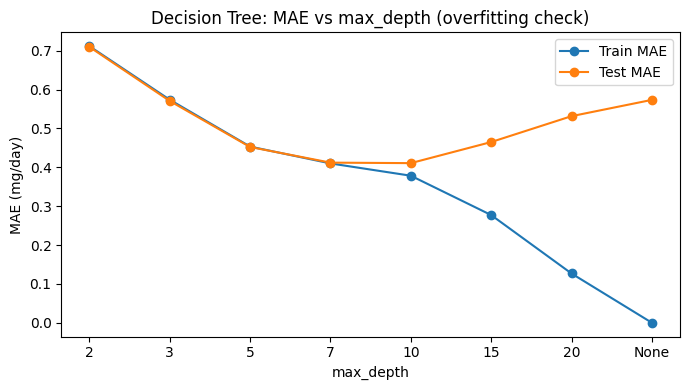

In [ ]:
# Validation curve evidence — MAE vs max_depth
depths_to_plot = [2, 3, 5, 7, 10, 15, 20, None]
cv_mae_by_depth = []
train_mae_by_depth = []

for d in depths_to_plot:
    tree = DecisionTreeRegressor(max_depth=d, random_state=42)
    tree.fit(X_train_encoded, y_train)
    train_pred = tree.predict(X_train_encoded)
    test_pred = tree.predict(X_test_encoded)
    train_mae_by_depth.append(mean_absolute_error(y_train, train_pred))
    cv_mae_by_depth.append(mean_absolute_error(y_test, test_pred))

depth_labels = [str(d) if d is not None else "None" for d in depths_to_plot]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(depth_labels, train_mae_by_depth, marker="o", label="Train MAE")
ax.plot(depth_labels, cv_mae_by_depth, marker="o", label="Test MAE")
ax.set_xlabel("max_depth")
ax.set_ylabel("MAE (mg/day)")
ax.set_title("Decision Tree: MAE vs max_depth (overfitting check)")
ax.legend()
plt.tight_layout()
plt.show()

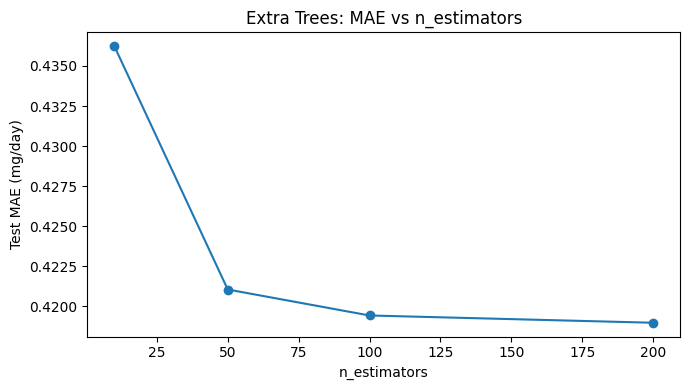

In [ ]:

# Same idea for Extra Trees: MAE vs n_estimators, to justify the final
# ensemble size rather than just picking 300 arbitrarily.
n_est_to_plot = [10, 50, 100, 200]
cv_mae_by_n = []
for n in n_est_to_plot:
    et = ExtraTreesRegressor(n_estimators=n, random_state=42, n_jobs=-1)
    et.fit(X_train_encoded, y_train)
    pred = et.predict(X_test_encoded)
    cv_mae_by_n.append(mean_absolute_error(y_test, pred))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(n_est_to_plot, cv_mae_by_n, marker="o")
ax.set_xlabel("n_estimators")
ax.set_ylabel("Test MAE (mg/day)")
ax.set_title("Extra Trees: MAE vs n_estimators")
plt.tight_layout()
plt.show()

Trying XGBoost too, want to see if boosting beats the Extra Trees result

In [ ]:
pip install xgboost

In [ ]:
from xgboost import XGBRegressor

# just a quick default run first before i bother tuning anything

In [ ]:
with mlflow.start_run(run_name='XGBoost_Engineered'):
    model = XGBRegressor(random_state=42, n_estimators=300, n_jobs=-1)
    model.fit(X_train_encoded, y_train)

    y_pred = model.predict(X_test_encoded)
    mae_xgb = mean_absolute_error(y_test, y_pred)
    rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred))
    r2_xgb = r2_score(y_test, y_pred)

    mlflow.log_params(model.get_params())
    mlflow.log_metrics({"mae": mae_xgb, "rmse": rmse_xgb, "r2": r2_xgb})
    mlflow.sklearn.log_model(model, 'model', skops_trusted_types=['xgboost.core.Booster', 'xgboost.sklearn.XGBRegressor'])

print(f"XGBoost (default) - MAE: {mae_xgb:.3f}, RMSE: {rmse_xgb:.3f}, R2: {r2_xgb:.3f}")

2026/08/04 22:46:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


XGBoost (default) - MAE: 0.425, RMSE: 0.578, R2: 0.873


not bad out the box, let's tune it properly and see how much more we can squeeze out

In [ ]:
xgb_param_grid = {
    "n_estimators": [10, 50,100, 200, ],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
}

xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=xgb_param_grid,
    n_iter=15,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=2,
    random_state=42,
    verbose=1,
    return_train_score=True,
)

xgb_search.fit(X_train_encoded, y_train)

print("Best XGBoost params:", xgb_search.best_params_)
print("Best CV MAE:", -xgb_search.best_score_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best XGBoost params: {'subsample': 0.85, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best CV MAE: 0.39685656033515926


In [ ]:
best_xgb = xgb_search.best_estimator_

y_pred_xgb = best_xgb.predict(X_test_encoded)
mae_xgb_tuned = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb_tuned = r2_score(y_test, y_pred_xgb)

with mlflow.start_run(run_name="XGBoost_Tuned"):
    mlflow.log_params(xgb_search.best_params_)
    mlflow.log_metrics({
        "mae": mae_xgb_tuned, "rmse": rmse_xgb_tuned, "r2": r2_xgb_tuned,
        "cv_mae": -xgb_search.best_score_,
    })
    mlflow.sklearn.log_model(best_xgb, "model", skops_trusted_types=['xgboost.core.Booster', 'xgboost.sklearn.XGBRegressor'])

print(f"XGBoost (tuned) - MAE: {mae_xgb_tuned:.3f}, RMSE: {rmse_xgb_tuned:.3f}, R2: {r2_xgb_tuned:.3f}")

2026/08/04 22:49:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


XGBoost (tuned) - MAE: 0.395, RMSE: 0.544, R2: 0.887


In [ ]:
# updating the comparison table from earlier so xgboost is in the mix too
comparison_full = pd.DataFrame({
    "Model": ["Decision Tree (default)", "Decision Tree (tuned)",
              "Extra Trees (default, n=300)", "Extra Trees (tuned)",
              "XGBoost (default)", "XGBoost (tuned)"],
    "MAE": [mae_dt, mae_dt_tuned, mae_et, mae_et_tuned, mae_xgb, mae_xgb_tuned],
    "RMSE": [rmse_dt, rmse_dt_tuned, rmse_et, rmse_et_tuned, rmse_xgb, rmse_xgb_tuned],
    "R2": [r2_dt, r2_dt_tuned, r2_et, r2_et_tuned, r2_xgb, r2_xgb_tuned],
})
comparison_full

,Model,MAE,RMSE,R2
0,Decision Tree (default),0.572370,0.795500,0.759190
1,Decision Tree (tuned),0.403919,0.556107,0.882318
2,"Extra Trees (default, n=300)",0.419484,0.577391,0.873137
3,Extra Trees (tuned),0.411493,0.566089,0.878055
4,XGBoost (default),0.424510,0.577639,0.873028
5,XGBoost (tuned),0.394588,0.544149,0.887325


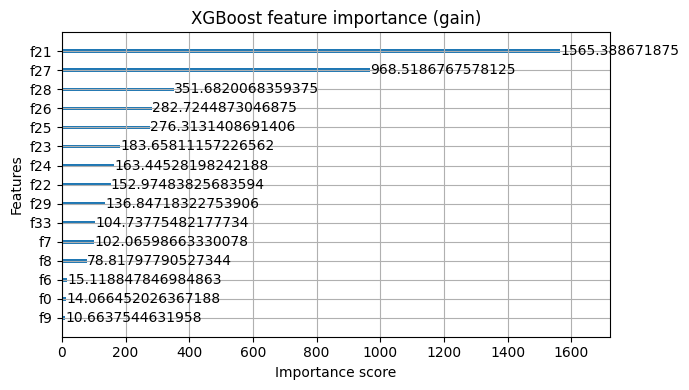

In [ ]:
# xgboost's own built in importance plot, quick sanity check before shap
from xgboost import plot_importance

fig, ax = plt.subplots(figsize=(7, 4))
plot_importance(best_xgb, ax=ax, max_num_features=15, importance_type='gain')
plt.title('XGBoost feature importance (gain)')
plt.tight_layout()
plt.show()

Machine Learning Black BOx

In [ ]:
pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=9bee8aaa3b89293dc790e715aa26b64028d871c745bdb73d48e952d51a9631cf
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
import lime
from lime.lime_tabular import LimeTabularExplainer
import numpy as np
import pandas as pd

# Ensure X_train_imputed.columns are available
feature_names = X_train_imputed.columns.tolist()

explainer = LimeTabularExplainer(
    training_data=X_train_encoded.toarray(), # Convert sparse matrix to dense array
    feature_names=feature_names, # Use column names from the imputed DataFrame
    class_names=['Final_Stable_Dose_mg'],
    mode='regression'
)

# Get the 5th instance from the sparse matrix and convert to a 1D dense array
instance = X_test_encoded[5].toarray()[0]

# Create a wrapper function for the model prediction that accepts a DataFrame
def predict_wrapper(data):
    # data will be a numpy array from LIME, convert it to DataFrame with feature names
    df_input = pd.DataFrame(data, columns=feature_names)
    return genexa_model.predict(df_input)

explanation = explainer.explain_instance(instance, predict_wrapper)
explanation.show_in_notebook()

Adding SHAP alongside LIME, want a second opinion on what's driving these predictions

In [ ]:
pip install shap

In [ ]:
import shap

# shap doesn't love sparse matrices so converting to a normal array first
X_test_dense = X_test_encoded.toarray() if hasattr(X_test_encoded, "toarray") else np.asarray(X_test_encoded)

# using the tuned xgboost model since TreeExplainer is built for boosted trees
explainer_shap = shap.TreeExplainer(best_xgb)
shap_values = explainer_shap.shap_values(X_test_dense)

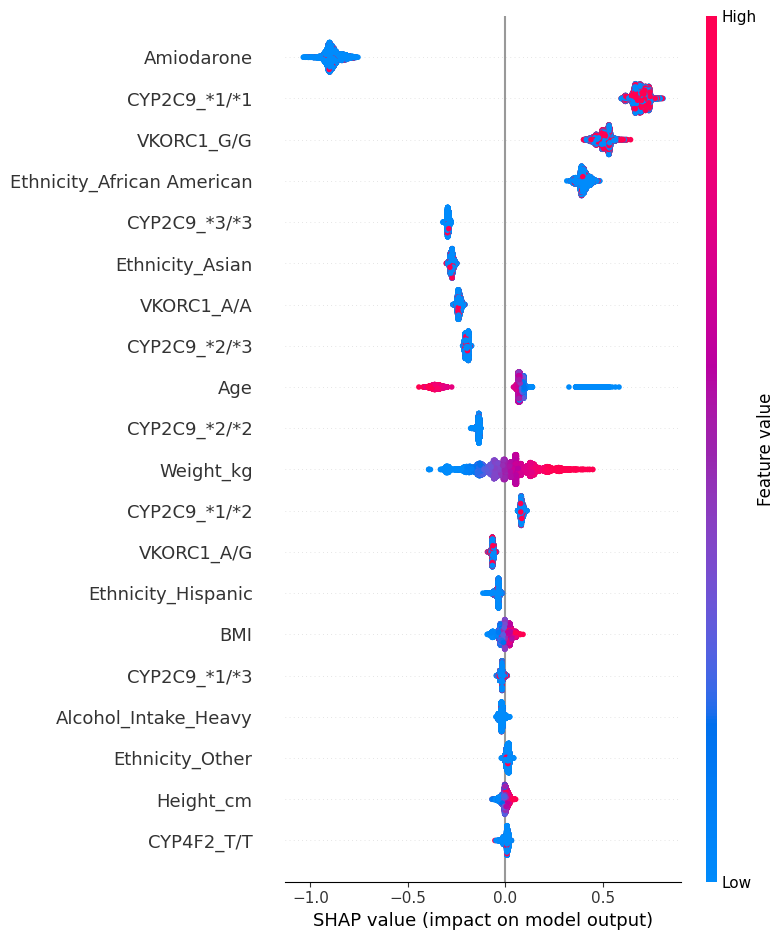

In [ ]:
# overall picture first, which features actually move the dose prediction the most
shap.summary_plot(shap_values, X_test_dense, feature_names=X_train_imputed.columns)

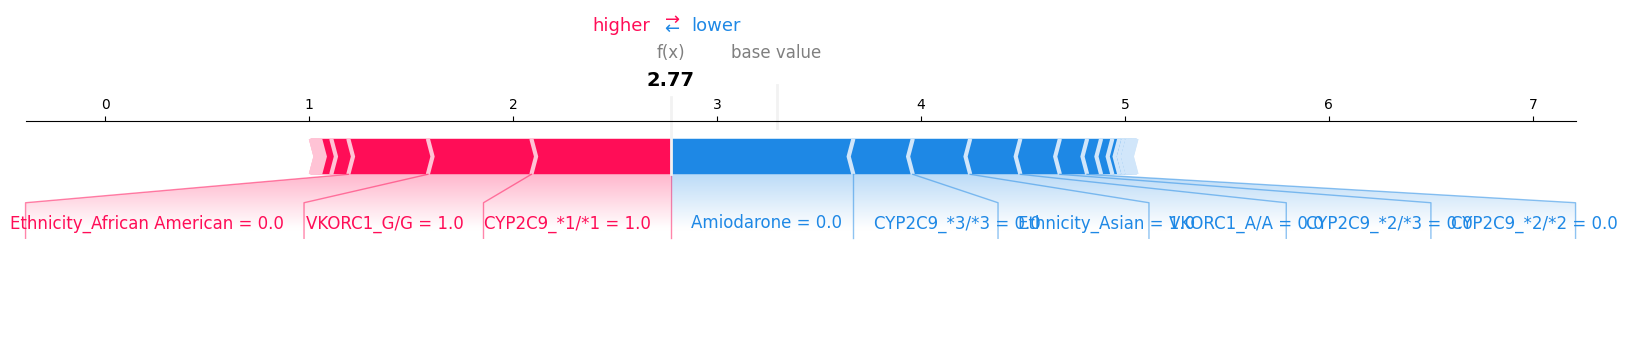

In [ ]:
# checking the same patient LIME looked at earlier (row 5), curious if shap agrees
shap.force_plot(
    explainer_shap.expected_value,
    shap_values[5],
    X_test_dense[5],
    feature_names=X_train_imputed.columns,
    matplotlib=True
)

LIME and SHAP telling a pretty similar story here, which is reassuring, genotype and age keep coming out on top either way

In [ ]:
!pip install gradio

In [ ]:
import os
import json
from typing import Dict, List, Tuple
import pandas as pd
import gradio as gr
import category_encoders as ce

# Configuration
# =========================
MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", "http://127.0.0.1:5000")
MODEL_NAME = os.getenv("MODEL_NAME", "Genexa_Warfarin_Dosing")
MODEL_VERSION = os.getenv("MODEL_VERSION", "1")  # or "Production"

DOSE_MIN, DOSE_MAX = 1.0, 10.0
DOSE_STEP = 0.5

In [ ]:
import subprocess
import time
import os

# Start MLflow UI in the background
# The default port for MLflow UI is 5000
# We redirect stdout and stderr to /dev/null to keep the output clean
mlflow_process = subprocess.Popen(["mlflow", "ui", "--host", "0.0.0.0", "--port", "5000"],
                                  stdout=subprocess.DEVNULL,
                                  stderr=subprocess.DEVNULL,
                                  preexec_fn=os.setsid)

print(f"MLflow UI started in the background on port 5000. PID: {mlflow_process.pid}")
print("Waiting for MLflow UI to start (10 seconds)...")
time.sleep(10) # Give it some time to start
print("MLflow UI should now be running. Please re-run the cell with the error and subsequent cells.")

MLflow UI started in the background on port 5000. PID: 25635
Waiting for MLflow UI to start (10 seconds)...
MLflow UI should now be running. Please re-run the cell with the error and subsequent cells.


In [ ]:
FALLBACK_TRAINED_COLUMNS = [
    "Age", "BMI", "Weight_kg", "Height_cm",
    "Sex_F", "Sex_M",
    "Ethnicity_African American", "Ethnicity_Asian", "Ethnicity_Caucasian", "Ethnicity_Hispanic", "Ethnicity_Other",
    "Alcohol_Intake_Light", "Alcohol_Intake_Moderate", "Alcohol_Intake_Heavy", "Alcohol_Intake_nan",
    "Smoking_Status_Former Smoker", "Smoking_Status_Non-smoker", "Smoking_Status_Smoker",
    "Diet_VitK_Intake_High", "Diet_VitK_Intake_Medium", "Diet_VitK_Intake_Low",
    "CYP2C9_*1/*1", "CYP2C9_*1/*2", "CYP2C9_*1/*3", "CYP2C9_*2/*2", "CYP2C9_*2/*3", "CYP2C9_*3/*3",
    "VKORC1_A/A", "VKORC1_A/G", "VKORC1_G/G",
    "CYP4F2_C/C", "CYP4F2_C/T", "CYP4F2_T/T",
    "On_Amiodarone",
    "Comorbidity_Burden",
    "Polypharamcy_index", "Polypharamcy_Index", "Polypharmacy_Index",
]

In [ ]:
CAT_SPECS = {
    "Sex": ["F", "M"],
    "Ethnicity": ["African American", "Asian", "Caucasian", "Hispanic", "Other"],
    "Alcohol_Intake": ["None", "Light", "Moderate", "Heavy"],
    "Diet_VitK_Intake": ["High", "Medium", "Low"],
    "Smoking_Status": ["Former Smoker", "Non-smoker", "Smoker"],
    "CYP2C9": ["*1/*1", "*1/*2", "*1/*3", "*2/*2", "*2/*3", "*3/*3"],
    "VKORC1": ["A/A", "A/G", "G/G"],
    "CYP4F2": ["C/C", "C/T", "T/T"],
}

In [ ]:
CATEGORICAL_COLS = [
    "Sex", "Ethnicity", "Alcohol_Intake", "Diet_VitK_Intake",
    "Smoking_Status", "CYP2C9", "VKORC1", "CYP4F2",
]

GENE_DEFAULTS = {"CYP2C9": "*1/*1", "VKORC1": "G/G", "CYP4F2": "C/C"}
COMORBS = ["Hypertension", "Diabetes", "Chronic_Kidney_Disease", "Heart_Failure"]
MEDS = ["Amiodarone", "Antibiotics", "Aspirin", "Statins"]

In [ ]:
def clip_and_round(dose: float, step: float = DOSE_STEP) -> float:
    dose = float(np.clip(dose, DOSE_MIN, DOSE_MAX))
    return round(step * round(dose / step), 2)


def ensure_genes(payload: Dict) -> Dict:
    fixed = payload.copy()
    for g, dflt in GENE_DEFAULTS.items():
        if fixed.get(g) in [None, "", "NA", "Unknown"]:
            fixed[g] = dflt
    return fixed

In [ ]:
def engineer_single(example: Dict) -> pd.DataFrame:
    ex = ensure_genes(example)
    row = {
        "Age": ex.get("Age"),
        "Weight_kg": ex.get("Weight_kg"),
        "Height_cm": ex.get("Height_cm"),
        "Sex": ex.get("Sex"),
        "Ethnicity": ex.get("Ethnicity"),
        "Alcohol_Intake": ex.get("Alcohol_Intake"),
        "Diet_VitK_Intake": ex.get("Diet_VitK_Intake"),
        "Smoking_Status": ex.get("Smoking_Status"),
        "CYP2C9": ex.get("CYP2C9"),
        "VKORC1": ex.get("VKORC1"),
        "CYP4F2": ex.get("CYP4F2"),
        "On_Amiodarone": int(ex.get("Amiodarone", 0) or ex.get("On_Amiodarone", 0)),
    }
    for c in COMORBS:
        row[c] = int(ex.get(c, 0))
    for m in MEDS:
        row[m] = int(ex.get(m, 0))

    df = pd.DataFrame([row])

    for col, cats in CAT_SPECS.items():
          if col in df.columns:
            df[col] = pd.Categorical(df[col], categories=cats, ordered=False)

    df["BMI"] = df["Weight_kg"] / ((df["Height_cm"] / 100.0) ** 2)
    df["Comorbidity_Burden"] = df[COMORBS].sum(axis=1)
    df["Polypharmacy_Index"] = df[MEDS].sum(axis=1)
    df["Polypharamcy_Index"] = df["Polypharmacy_Index"]
    df["Polypharamcy_index"] = df["Polypharmacy_Index"]

    engineered_cols = [
        "Age", "Weight_kg", "Height_cm", "Sex", "Ethnicity",
        "Alcohol_Intake", "Diet_VitK_Intake", "Smoking_Status",
        "CYP2C9", "VKORC1", "CYP4F2", "On_Amiodarone",
        "BMI", "Comorbidity_Burden",
        "Polypharmacy_Index", "Polypharamcy_Index", "Polypharamcy_index",
    ]
    return df[engineered_cols]

In [ ]:
def load_trained_columns(model) -> List[str]:
    if os.path.exists("trained_columns.json"):
        try:
            with open("trained_columns.json", "r") as f:
                cols = json.load(f)
            if isinstance(cols, list) and len(cols) > 0:
                return cols
        except Exception:
            pass
    try:
        cols = list(model.feature_names_in_)
        if len(cols) > 0:
            return cols
    except Exception:
        pass
    return FALLBACK_TRAINED_COLUMNS

In [ ]:
def to_model_matrix(df_one: pd.DataFrame, trained_columns: List[str]) -> pd.DataFrame:
    enc = ce.OneHotEncoder(
        cols=CATEGORICAL_COLS,
        use_cat_names=True,
        handle_unknown="ignore",
        handle_missing="value"
    )
    X = enc.fit_transform(df_one)
    X = X.reindex(columns=trained_columns, fill_value=0)
    return X

In [ ]:
def engineer_single(example: Dict) -> pd.DataFrame:
    ex = ensure_genes(example)
    row = {
        "Age": ex.get("Age"),
        "Weight_kg": ex.get("Weight_kg"),
        "Height_cm": ex.get("Height_cm"),
        "Sex": ex.get("Sex"),
        "Ethnicity": ex.get("Ethnicity"),
        "Alcohol_Intake": ex.get("Alcohol_Intake"),
        "Diet_VitK_Intake": ex.get("Diet_VitK_Intake"),
        "Smoking_Status": ex.get("Smoking_Status"),
        "CYP2C9": ex.get("CYP2C9"),
        "VKORC1": ex.get("VKORC1"),
        "CYP4F2": ex.get("CYP4F2"),
        "On_Amiodarone": int(ex.get("Amiodarone", 0) or ex.get("On_Amiodarone", 0)),
    }
    for c in COMORBS:
        row[c] = int(ex.get(c, 0))
    for m in MEDS:
        row[m] = int(ex.get(m, 0))

    df = pd.DataFrame([row])

    for col, cats in CAT_SPECS.items():
        if col in df.columns:
            df[col] = pd.Categorical(df[col], categories=cats, ordered=False)

    df["BMI"] = df["Weight_kg"] / ((df["Height_cm"] / 100.0) ** 2)
    df["Comorbidity_Burden"] = df[COMORBS].sum(axis=1)
    df["Polypharmacy_Index"] = df[MEDS].sum(axis=1)
    df["Polypharamcy_Index"] = df["Polypharmacy_Index"]
    df["Polypharamcy_index"] = df["Polypharmacy_Index"]

    engineered_cols = [
        "Age", "Weight_kg", "Height_cm", "Sex", "Ethnicity",
        "Alcohol_Intake", "Diet_VitK_Intake", "Smoking_Status",
        "CYP2C9", "VKORC1", "CYP4F2", "On_Amiodarone",
        "BMI", "Comorbidity_Burden",
        "Polypharmacy_Index", "Polypharamcy_Index", "Polypharamcy_index",
    ]
    return df[engineered_cols]


def load_trained_columns(model) -> List[str]:
    if os.path.exists("trained_columns.json"):
        try:
            with open("trained_columns.json", "r") as f:
                cols = json.load(f)
            if isinstance(cols, list) and len(cols) > 0:
                return cols
        except Exception:
            pass
    try:
        cols = list(model.feature_names_in_)
        if len(cols) > 0:
            return cols
    except Exception:
        pass
    return FALLBACK_TRAINED_COLUMNS

def to_model_matrix(df_one: pd.DataFrame, trained_columns: List[str]) -> pd.DataFrame:
    enc = ce.OneHotEncoder(
        cols=CATEGORICAL_COLS,
        use_cat_names=True,
        handle_unknown="ignore",
        handle_missing="value"
    )
    X = enc.fit_transform(df_one)
    X = X.reindex(columns=trained_columns, fill_value=0)
    return X
# =========================
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
MODEL_URI = f"models:/{MODEL_NAME}/{MODEL_VERSION}"
champion_model = mlflow.sklearn.load_model(MODEL_URI)
TRAINED_COLUMNS = load_trained_columns(champion_model)


# =========================
# Gradio predict function
# =========================
def predict_fn(
    Age, Weight_kg, Height_cm, Sex, Ethnicity,
    Alcohol_Intake, Diet_VitK_Intake, Smoking_Status,
    CYP2C9, VKORC1, CYP4F2,
    Hypertension, Diabetes, Chronic_Kidney_Disease, Heart_Failure,
    Amiodarone, Antibiotics, Aspirin, Statins
):
    payload = {
        "Age": Age, "Weight_kg": Weight_kg, "Height_cm": Height_cm,
        "Sex": Sex, "Ethnicity": Ethnicity,
        "Alcohol_Intake": Alcohol_Intake, "Diet_VitK_Intake": Diet_VitK_Intake, "Smoking_Status": Smoking_Status,
        "CYP2C9": CYP2C9, "VKORC1": VKORC1, "CYP4F2": CYP4F2,
        "Hypertension": int(Hypertension), "Diabetes": int(Diabetes),
        "Chronic_Kidney_Disease": int(Chronic_Kidney_Disease), "Heart_Failure": int(Heart_Failure),
        "Amiodarone": int(Amiodarone), "Antibiotics": int(Antibiotics),
        "Aspirin": int(Aspirin), "Statins": int(Statins),
    }

    df_one = engineer_single(payload)
    X_one = to_model_matrix(df_one, TRAINED_COLUMNS)

    raw_pred = float(champion_model.predict(X_one)[0])
    dose = clip_and_round(raw_pred, step=DOSE_STEP)
    return f"{dose} mg/day", f"{raw_pred:.3f} mg/day", df_one, X_one


# =========================
# Build Gradio UI (inline)
# =========================
with gr.Blocks(title="Genexa Warfarin Dosing (Jupyter Prototype)") as demo:
    gr.Markdown("## 💊 Genexa Warfarin Dosing — Prototype (Inline in Notebook)")
    gr.Markdown("*Not for clinical use.*")

    with gr.Row():
        with gr.Column():
            gr.Markdown("### Demographics")
            Age = gr.Slider(18, 100, value=67, step=1, label="Age")
            Weight_kg = gr.Slider(30, 200, value=75, step=0.5, label="Weight (kg)")
            Height_cm = gr.Slider(120, 220, value=170, step=0.5, label="Height (cm)")
            Sex = gr.Radio(["M", "F"], value="M", label="Sex")
            Ethnicity = gr.Dropdown(["African American", "Asian", "Caucasian", "Hispanic", "Other"],
                                    value="Caucasian", label="Ethnicity")

            gr.Markdown("### Lifestyle")
            Alcohol_Intake = gr.Dropdown(["None", "Light", "Moderate", "Heavy"],
                                         value="Light", label="Alcohol Intake")
            Diet_VitK_Intake = gr.Dropdown(["High", "Medium", "Low"],
                                           value="Medium", label="Vitamin K Intake")
            Smoking_Status = gr.Dropdown(["Former Smoker", "Non-smoker", "Smoker"],
                                         value="Non-smoker", label="Smoking Status")

        with gr.Column():
            gr.Markdown("### Genomics & Clinical Info")
            CYP2C9 = gr.Dropdown(["*1/*1", "*1/*2", "*1/*3", "*2/*2", "*2/*3", "*3/*3"],
                                 value="*1/*2", label="CYP2C9")
            VKORC1 = gr.Dropdown(["A/A", "A/G", "G/G"], value="A/G", label="VKORC1")
            CYP4F2 = gr.Dropdown(["C/C", "C/T", "T/T"], value="C/T", label="CYP4F2")

            Hypertension = gr.Checkbox(True, label="Hypertension")
            Diabetes = gr.Checkbox(False, label="Diabetes")
            Chronic_Kidney_Disease = gr.Checkbox(False, label="Chronic Kidney Disease")
            Heart_Failure = gr.Checkbox(False, label="Heart Failure")

            gr.Markdown("### Medications")
            Amiodarone = gr.Checkbox(False, label="Amiodarone")
            Antibiotics = gr.Checkbox(False, label="Antibiotics")
            Aspirin = gr.Checkbox(True, label="Aspirin")
            Statins = gr.Checkbox(True, label="Statins")

    predict_btn = gr.Button("🔍 Predict Dose")

    with gr.Row():
        with gr.Column():
            dose_out = gr.Textbox(label="Recommended Dose (guardrailed)", interactive=False)
            raw_out = gr.Textbox(label="Raw Model Prediction (pre-guardrails)", interactive=False)
        with gr.Column():
            with gr.Accordion("Engineered Feature Row", open=False):
                eng_out = gr.Dataframe(wrap=True)
            with gr.Accordion("Model Matrix Row", open=False):
                X_out = gr.Dataframe(wrap=True)

    predict_btn.click(
        fn=predict_fn,
        inputs=[
            Age, Weight_kg, Height_cm, Sex, Ethnicity,
            Alcohol_Intake, Diet_VitK_Intake, Smoking_Status,
            CYP2C9, VKORC1, CYP4F2,
            Hypertension, Diabetes, Chronic_Kidney_Disease, Heart_Failure,
            Amiodarone, Antibiotics, Aspirin, Statins
        ],
        outputs=[dose_out, raw_out, eng_out, X_out]
    )
demo.launch(inline=True, share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://89a07ac179f0f7bee9.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
